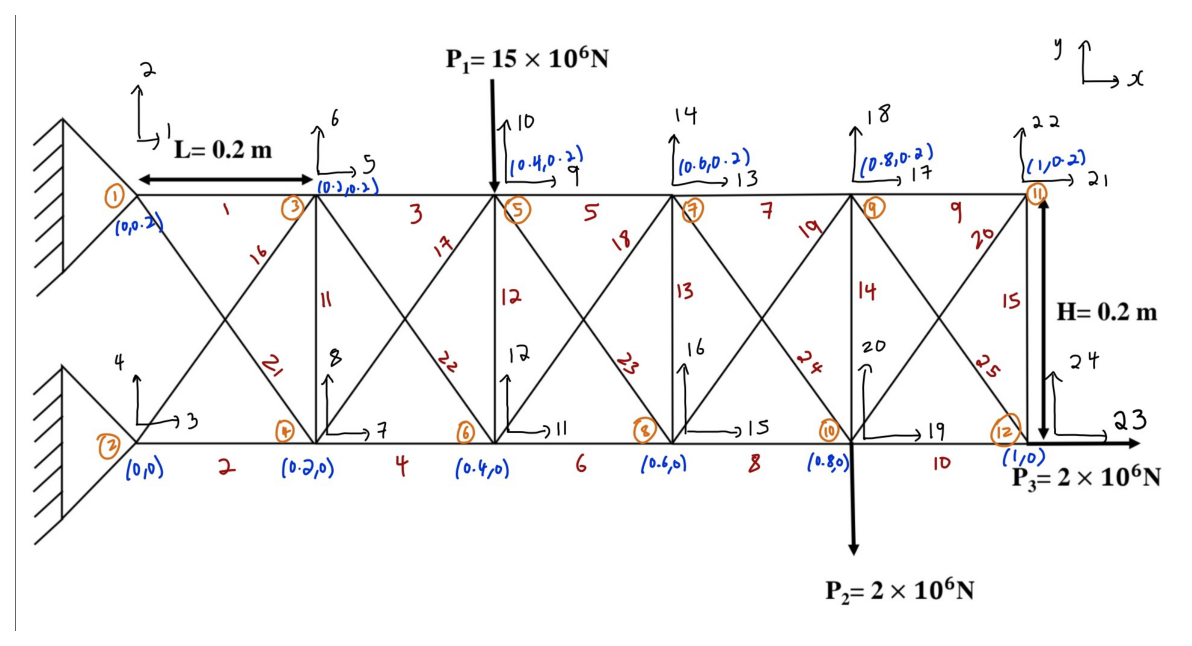

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(r"C:\Users\10H17\Downloads\Question3.jpg")

plt.figure(figsize=(10,6), dpi=150) 
plt.imshow(img)
plt.axis('off')
plt.show()

Importing necessart modules.

In [2]:
import numpy as np
import calfem.core as cfc
import pandas as pd

Defining Topology, element 1 has axis 1,2,5,6 and element 2 has 3,4,7,8 and so on

In [40]:
Edof = np.array([
    [1, 2, 5, 6],
    [3, 4, 7, 8],
    [5, 6, 9, 10],
    [7, 8, 11, 12],
    [9, 10, 13, 14],
    [11, 12, 15, 16],
    [13, 14, 17, 18],
    [15, 16, 19, 20],
    [17, 18, 21, 22],
    [19, 20, 23, 24],
    [7, 8, 5, 6],
    [11, 12, 9, 10],
    [15, 16, 13, 14],
    [19, 20, 17, 18],
    [23, 24, 21, 22],
    [3, 4, 5, 6],
    [7, 8, 9, 10],
    [11, 12, 13, 14],
    
    [15, 16, 17, 18],
    [19, 20, 21, 22],
    [1, 2, 7, 8],
    [5, 6, 11, 12],
    [9, 10, 15, 16],
    [13, 14, 19, 20],
    [17, 18, 23, 24]
])

Defining K, f matrix size

In [4]:
K = np.zeros([24,24])
f = np.zeros([24,1])

Giving Area and Young's modulus values

In [5]:
A = 0.2
E = 2e11
ep = [E,A]

Global coordinate matrix coord and a global topology matrix Dof is defined

In [27]:
#Coordinate of each node from node 1 to 12
Coord = np.array([
[0, 0.2],
[0,0],
[0.2,0.2],
[0.2,0],
[0.4,0.2],
[0.4,0],
[0.6,0.2],
[0.6,0],
[0.8,0.2],
[0.8,0],
[1,0.2],
[1,0]
])

#Each axis number correspoidng to each node from 1 to 12
Dof = np.array([
[1, 2],
[3, 4],
[5, 6],
[7, 8],
[9, 10],
[11, 12],
[13, 14],
[15, 16],
[17, 18],
[19, 20],
[21, 22],
[23, 24]
])
ex, ey = cfc.coordxtr(Edof, Coord, Dof)

Loop is run to assemble the matrices

In [28]:
for elx, ely, eltopo in zip(ex, ey, Edof):
    Ke = cfc.bar2e(elx, ely, ep)
    cfc.assem(eltopo, K, Ke)

Boundary conditions are given

In [29]:
bc = np.array([1,2,3,4])

f[9] = -15e6
f[19] = -2e6
f[22] = 2e6


a, r = cfc.solveq(K,f,bc)

Displacement values at each node

In [30]:
ux = a[0::2].flatten()
uy = a[1::2].flatten()

table = pd.DataFrame({
    "Node": range(1, 13),
    "ux": ux,
    "uy": uy
})

print(table)

    Node        ux        uy
0      1  0.000000  0.000000
1      2  0.000000  0.000000
2      3  0.000049 -0.000087
3      4 -0.000046 -0.000088
4      5  0.000070 -0.000247
5      6 -0.000063 -0.000236
6      7  0.000076 -0.000383
7      8 -0.000064 -0.000383
8      9  0.000077 -0.000528
9     10 -0.000063 -0.000528
10    11  0.000077 -0.000666
11    12 -0.000060 -0.000666


Reaction forces at each node

In [31]:
fx = r[0::2].flatten()
fy = r[1::2].flatten()

table = pd.DataFrame({
    "Node": range(1, 13),
    "fx": fx,
    "fy": fy
})

print(table)

    Node            fx            fy
0      1 -3.800000e+07  8.793776e+06
1      2  3.600000e+07  8.206224e+06
2      3 -7.450581e-09 -1.862645e-09
3      4  7.450581e-09  0.000000e+00
4      5  0.000000e+00  4.470348e-08
5      6  1.490116e-08 -5.587935e-09
6      7 -2.980232e-08 -4.097819e-08
7      8  3.725290e-08 -1.862645e-09
8      9  1.490116e-08  1.862645e-09
9     10 -1.490116e-08  8.754432e-08
10    11 -2.235174e-08 -4.842877e-08
11    12  7.450581e-09  1.564622e-07


Visualising deformation via plot

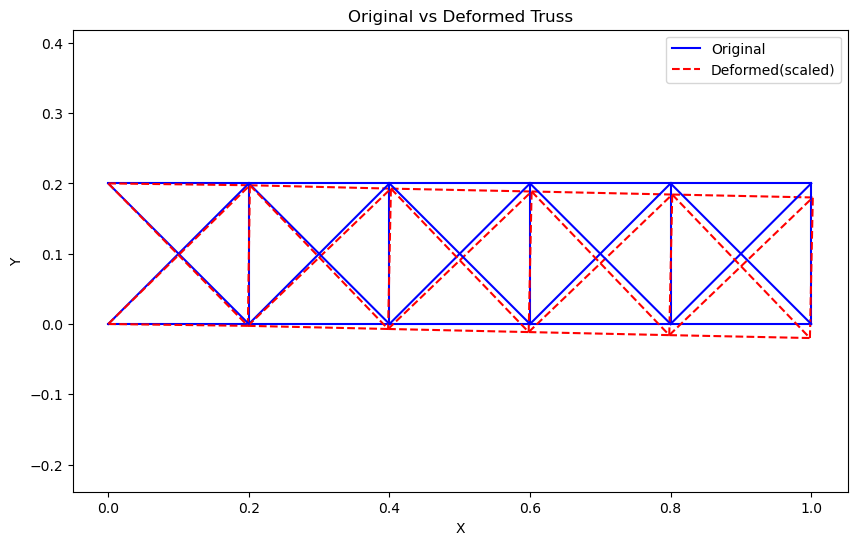

In [43]:
scale = 30
deformed = Coord + scale * np.column_stack((ux, uy))

plt.figure(figsize=(10,6))

for el in Edof:
    n1 = (el[0] - 1) // 2
    n2 = (el[2] - 1) // 2

    plt.plot([Coord[n1,0], Coord[n2,0]],
             [Coord[n1,1], Coord[n2,1]], 'b-')

    plt.plot([deformed[n1,0], deformed[n2,0]],
             [deformed[n1,1], deformed[n2,1]], 'r--')

plt.title("Original vs Deformed Truss")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.legend(["Original", "Deformed(scaled)"])
plt.show()